In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [8]:
df = pd.read_csv("/content/drive/MyDrive/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_629/3692201336.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [11]:
df.drop("customerID", axis=1, inplace=True)

In [12]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

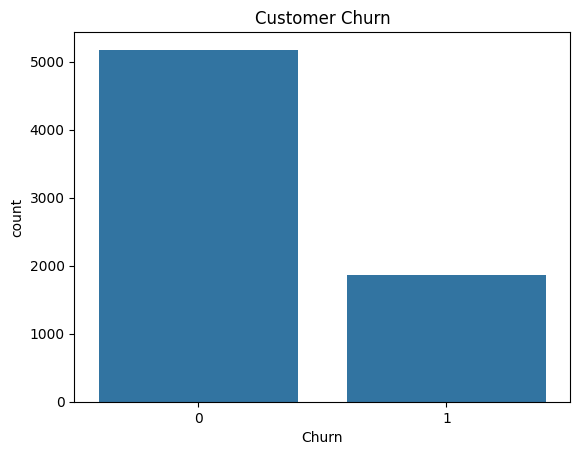

In [13]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn")
plt.show()

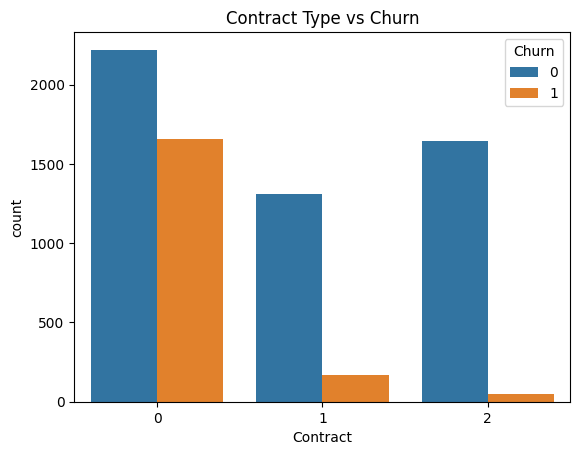

In [14]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

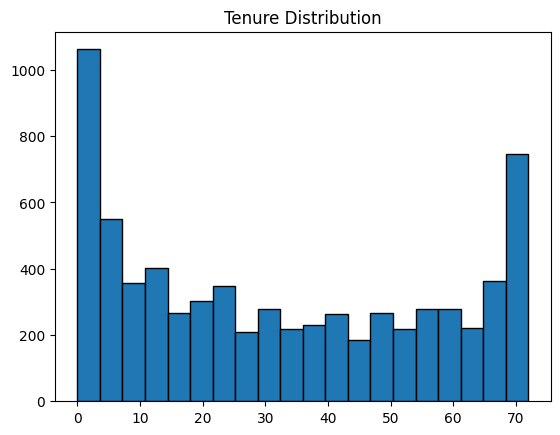

In [15]:
plt.hist(df["tenure"], bins=20, edgecolor="black")
plt.title("Tenure Distribution")
plt.show()

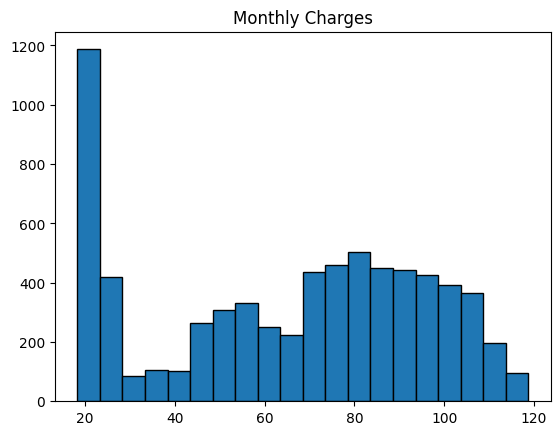

In [16]:
plt.hist(df["MonthlyCharges"], bins=20, edgecolor="black")
plt.title("Monthly Charges")
plt.show()

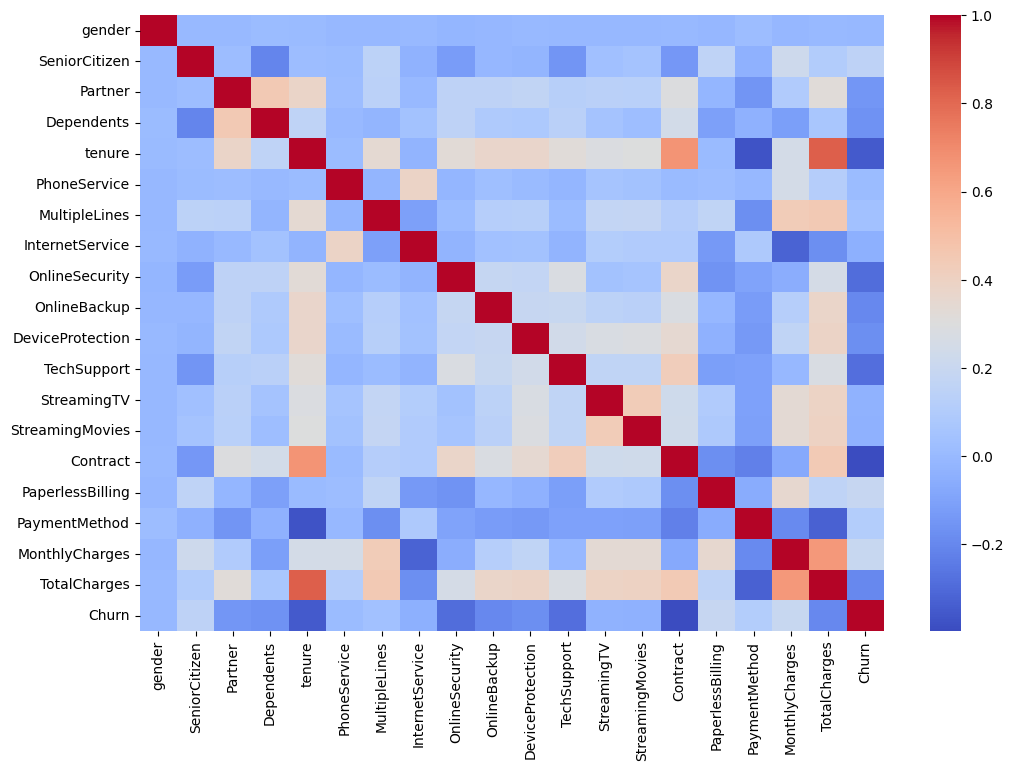

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [18]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


The dataset is slightly imbalanced because customers who did not churn are more than customers who churned.

In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
tree_pred = tree.predict(X_test)
print("Decision Tree Accuracy")
print(accuracy_score(y_test, tree_pred))

Decision Tree Accuracy
0.7253371185237757


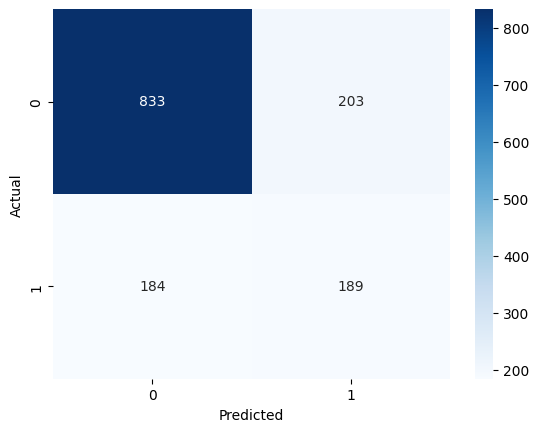

In [23]:
cm = confusion_matrix(y_test, tree_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.49       373

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [25]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [26]:
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy")
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy
0.8161816891412349


In [27]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [28]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Decision Tree Accuracy: 0.7253371185237757
Logistic Regression Accuracy: 0.8161816891412349


In [29]:
importance = pd.DataFrame(
{
    "Feature": X.columns,
    "Importance": tree.feature_importances_
}
)

In [30]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
17,MonthlyCharges,0.215873
18,TotalCharges,0.200148
14,Contract,0.166295
4,tenure,0.111674
16,PaymentMethod,0.046128
8,OnlineSecurity,0.044898
15,PaperlessBilling,0.028275
7,InternetService,0.026732
0,gender,0.023367
2,Partner,0.020851


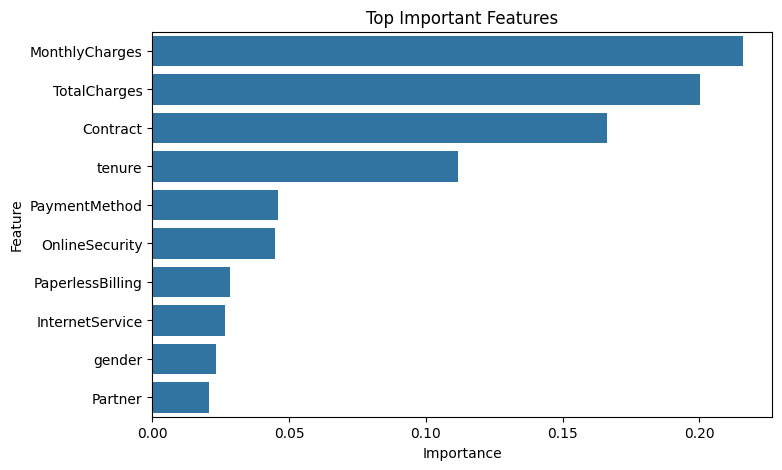

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)
plt.title("Top Important Features")
plt.show()

In [32]:
importance.head(3)

,Feature,Importance
17,MonthlyCharges,0.215873
18,TotalCharges,0.200148
14,Contract,0.166295


The analysis shows that Monthly Charges, Total Charges, and Contract Type are the most important factors influencing customer churn. Customers with higher monthly charges and certain contract types are more likely to leave the company. Both the Decision Tree and Logistic Regression models were trained to predict customer churn, and their performance was compared. These findings can help the company identify customers who are at risk of leaving and improve customer retention through better pricing strategies and long-term contract offers.

Logistic Regression performed better than the Decision Tree, achieving an accuracy of 81.68%. Therefore, it is the preferred model for predicting customer churn on this dataset.